In [130]:
import pandas as pd
import os
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV,RandomizedSearchCV
from sklearn.metrics import log_loss, confusion_matrix, classification_report,roc_curve
from sklearn.utils import resample
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
file_path = "./Synthetic_Financial_datasets_log.csv"
df = pd.read_csv(file_path)
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [45]:
encoder = OneHotEncoder(sparse_output=False)
columns_to_encode = ['type']

encoded = encoder.fit_transform(df[columns_to_encode])
encoded_columns = encoder.get_feature_names_out(columns_to_encode)
encoded_df = pd.DataFrame(encoded, columns=encoded_columns)

df = pd.concat([df, encoded_df], axis=1)
print(df.head())

   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  ...  type_CASH_IN  \
0  M1979787155             0.0             0.0        0  ...           0.0   
1  M2044282225             0.0             0.0        0  ...           0.0   
2   C553264065             0.0             0.0        1  ...           0.0   
3    C38997010         21182.0             0.0        1  ...           0.0   
4  M1230701703             0.0             0.0        0  ...           0.0   

   type_CASH_OUT  type_DEBIT  type_PAYMENT  type_TRANSFER  type_CASH_IN  \
0    

In [80]:
labels = ['isFraud', 'isFlaggedFraud']
features = ['step', 'amount'] + encoded_columns.tolist()
features
train_size=0.7
train_index_split = int(train_size*df.shape[0])

train, test = df[:train_index_split], df[train_index_split:]

In [81]:
# Separate by class
min_class_size = train['isFraud'].value_counts().min()

# Downsample each class
train_balanced = (
    train.groupby('isFraud', group_keys=False)
      .apply(lambda x: x.sample(min_class_size, random_state=42))
)

print(train_balanced['isFraud'].value_counts())

isFraud
0    3643
1    3643
Name: count, dtype: int64


/tmp/ipython-input-3258476427.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min_class_size, random_state=42))


In [82]:
X_train, y_train = train_balanced[features], train_balanced[['isFraud']]
X_test, y_test = test[features], test[['isFraud']]

print(y_train.value_counts())
print(y_test.value_counts())

isFraud
0          3643
1          3643
Name: count, dtype: int64
isFraud
0          1904216
1             4570
Name: count, dtype: int64


In [134]:
def model_prediction(model, X_train, y_train, X_test, y_test):
  model.fit(X_train.to_numpy(), y_train.to_numpy())

  # Predict probabilities and classes for the test set
  y_pred_proba = model.predict_proba(X_test.to_numpy())
  y_pred = model.predict(X_test.to_numpy())

  # Calculate the mlogloss
  mlogloss = log_loss(y_test, y_pred_proba)
  print(f"Log Loss: {mlogloss}\n")

  # Generate the confusion matrix
  conf_matrix = confusion_matrix(y_test, y_pred)
  sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=y_test['isFraud'].unique(), yticklabels=y_test['isFraud'].unique())

  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.title('Confusion Matrix')
  plt.show()

  # Display a classification report for additional metrics
  class_report = classification_report(y_test, y_pred, target_names=["0","1"])
  print("Classification Report:")
  print(class_report)

  # Plot ROC-AUC
  fpr, tpr, _ = roc_curve(y_test, y_pred)
  plt.plot(fpr, tpr)
  plt.xlabel("False Positive Rate")
  plt.ylabel("True Positive Rate")
  plt.title("ROC-AUC Curve")
  plt.show()


# Simple XGBoost

Log Loss: 0.47933254503256423



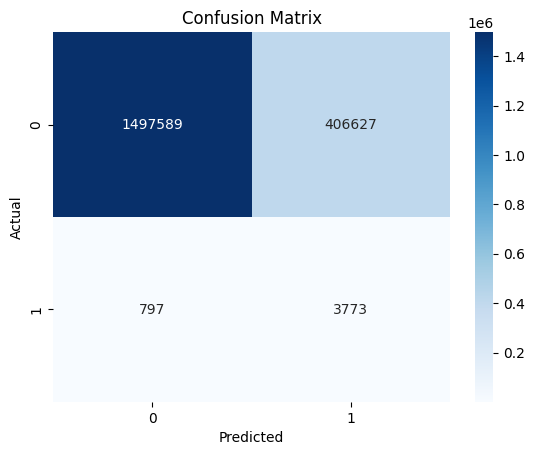

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.79      0.88   1904216
           1       0.01      0.83      0.02      4570

    accuracy                           0.79   1908786
   macro avg       0.50      0.81      0.45   1908786
weighted avg       1.00      0.79      0.88   1908786



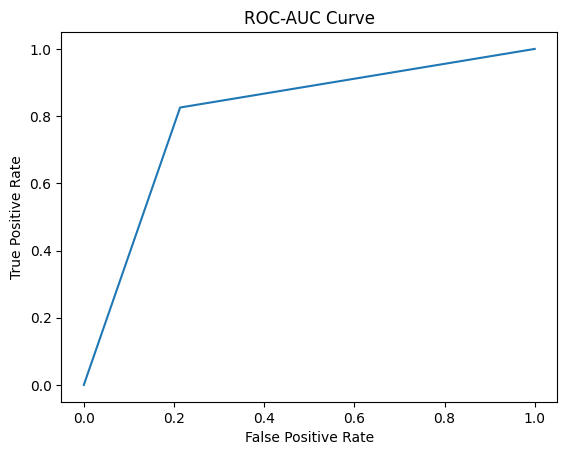

In [135]:
# XGBoost without hyperparameter tuning
model = xgb.XGBClassifier(eval_metric='mlogloss',random_state=42)
model_prediction(model, X_train, y_train, X_test, y_test)

# XGBoost with Hyperparameter tuning

In [132]:
# Define the XGBoost model
param_dist = {
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth': [3, 5, 6],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'n_estimators': [100, 200, 300]
}

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(model, param_distributions=param_dist, n_iter=10, scoring='f1_weighted', cv=5, random_state=42)

# Fit the randomized search to the data
random_search.fit(X_train.to_numpy(), y_train.to_numpy())

# Get the best parameters
best_params = random_search.best_params_
# Print the best parameters
print("Best Parameters:", best_params)

Best Parameters: {'subsample': 1.0, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 1.0}


Log Loss: 0.3242640568621586



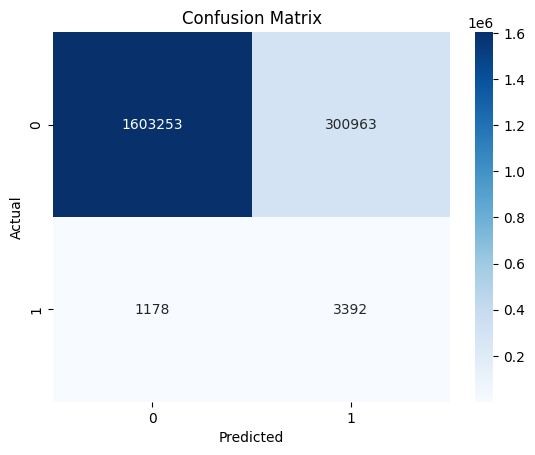

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.84      0.91   1904216
           1       0.01      0.74      0.02      4570

    accuracy                           0.84   1908786
   macro avg       0.51      0.79      0.47   1908786
weighted avg       1.00      0.84      0.91   1908786



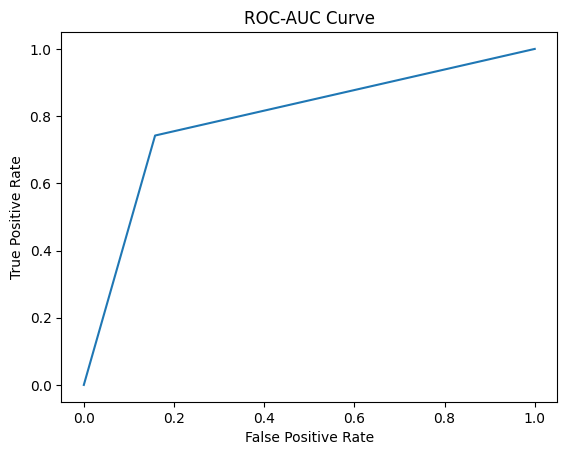

In [136]:
model_tuned = xgb.XGBClassifier(
    learning_rate=best_params['learning_rate'],
    max_depth=best_params['max_depth'],
    min_child_weight=best_params['min_child_weight'],
    subsample=best_params['subsample'],
    colsample_bytree=best_params['colsample_bytree'],
    n_estimators=best_params['n_estimators'],
    importance_type='gain',
    eval_metric='mlogloss',random_state=42
)

model_prediction(model_tuned, X_train, y_train, X_test, y_test)